# House Prices: Advanced Regression Techniques - Data Preprocessing Lab


In this lab, we will work with the Kaggle **House Prices: Advanced Regression Techniques** dataset.  
We will cover:
1. Reading the dataset  
2. Exploratory Data Analysis (EDA)  
3. Handling Missing Values  
4. Encoding Categorical Variables  
5. Detecting & Removing Outliers (Z-score and IQR methods)  
6. Feature Selection using Correlation  
7. Dimensionality Reduction using PCA  

This will give you a complete hands-on workflow for preparing data for machine learning.


In [16]:
# Importing neccessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Task 1: Reading the Dataset
Read the dataset using Pandas with default indexing. 

In [17]:
df = pd.read_csv("house_train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 2: Exploratory Data Analysis (EDA)
We check basic statistics and visualize missing values, distributions, etc.

In [18]:
# Basic info
# Find the missing values
# Find the statistical data analysis on the data
print(df.info())
print(df.describe(include='all'))
print(df.columns)
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.tail())
print(df.isnull().sum())
print(df.describe(include='all').transpose())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Step 3: Handling Missing Values
We can fill missing numeric values with median and categorical with mode.

In [19]:
# Fill numeric columns with median
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode())

df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

## Step 4: Encoding Categorical Variables
Convert categorical (string) values into numbers using One-Hot Encoding.

In [20]:
# One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


## Step 5: Outlier Detection
Use Z-scores to find outliers 

In [21]:
# use Z score to identify outliers display the rows having outliers but do not remove them for now. 

# Original shape
print(f"Original shape: {df.shape}")

# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute Z scores
z_scores = np.abs(stats.zscore(numeric_df))

# Define threshold for outliers
threshold = 3

# Find rows where any column has a Z-score greater than threshold
outlier_mask = (z_scores > threshold).any(axis=1)
outliers = df[outlier_mask]

# Without outliers
df_no_outliers = df[~outlier_mask]
print(f"After removing outliers (Z-score): {df_no_outliers.shape}")

Original shape: (1460, 289)
After removing outliers (Z-score): (1015, 289)


## Step 6: Outlier Detection and Removal (IQR)
We use IQR to detect and remove outliers.

In [ ]:
# Us from scratch IQR method to identify and remove outliers. Please make comparative study between z-score and IQR in identifying better method for identification of outliers on our dataset. 

# Original shape
print(f"Original shape: {df.shape}")

# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

# Computer IQR for each column
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Create mask for outliers
outlier_mask_iqr = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

# Extract outliers
outliers_iqr = df[outlier_mask_iqr]

# Remove outliers
df = df[~outlier_mask_iqr]

print(f"After removing outliers (IQR): {df.shape}")

Original shape: (1460, 81)
After removing outliers (IQR): (557, 81)


## Step 7: Feature Selection using Correlation
We check correlation with the target variable `SalePrice`. Variables with high correlation are more predictive.

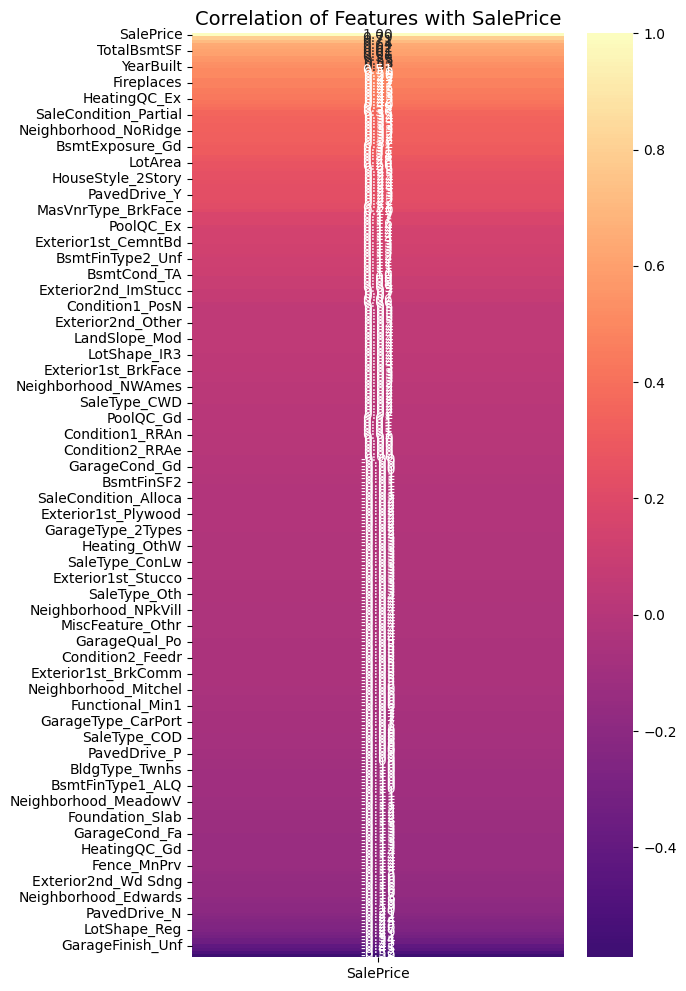

In [23]:
# Take SalePrice as a reference column and find 10 of the most highest correlated columns to price. 
# For Machine Learning purposes and draw their heatmap.

# Compute correlation with SalePrice
corr_with_saleprice = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

# Convert to DataFrame for plotting
corr_df = corr_with_saleprice.to_frame()

# Plot heatmap
plt.figure(figsize=(6,12))
sns.heatmap(corr_df, annot=True, cmap="magma", center=0, fmt=".2f", cbar=True)
plt.title("Correlation of Features with SalePrice", fontsize=14)
plt.show()

## Step 8: Dimensionality Reduction using PCA
We use Principal Component Analysis (PCA) to reduce dimensionality.

In [24]:
# Reduce the dimensions of the data using PCA. Convert the columns into two prinicple component only. 

# Select only numeric features for PCA
X = df.select_dtypes(include=[np.number])

# Standardize features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Print explained variance ratio
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Convert PCA result into DataFrame for easy usage
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
print(pca_df.head())

Explained variance ratio: [0.20776907 0.08437885]
        PC1       PC2
0  1.502500  0.360729
1 -0.002220 -1.096013
2  1.741289  0.235336
3 -0.499102  1.008752
4  4.459606  1.130126
